In [2]:
all = [var for var in globals() if var[0] != "_"]
for var in all:
    del globals()[var]

del var, all
# This script clears all global variables except those starting with an underscore.

In [3]:
# Modeule imports
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import torch

import scipy.optimize as sci_opt
from scipy.optimize import NonlinearConstraint
import scipy.special
import module_opt_AD as my_opt

import matplotlib.pyplot as plt

import heat_equation_2D_for_students
import heat_equation_2D_for_students_jax

import importlib
importlib.reload(my_opt)
importlib.reload(heat_equation_2D_for_students)
importlib.reload(heat_equation_2D_for_students_jax)

from heat_equation_2D_for_students import HeatEquation2D
from heat_equation_2D_for_students_jax import HeatEquation2D_JAX

## Optimization - Finite Differetiation(FD) & Scaling

In [114]:
lx = .04  # length in x direction
ly = .04  # length in y direction
z = .04  # height of the domain
N = 25    # number of grid points in x, y direction
k_Si = 149  # thermal conductivity of silicon
rho_Si = 2323  # density of silicon
cp_Si = 704.611  # specific heat capacity of silicon
CFL = .1 # CFL number

def T0(x:np.ndarray, y:np.ndarray) -> np.ndarray:
    """
    Initial temperature distribution over the domain.
    """
    T_0 = np.zeros_like(x)
    ## Cosine Case
    T_0 = 70 * np.sin(x * np.pi / lx) * np.sin(y * np.pi / ly) + 293
    return T_0

heq_FD_scaling = HeatEquation2D(x=lx, y=ly, height=z, n_x=N, n_y=N, k=k_Si, rho=rho_Si, cp=cp_Si, CFL=CFL, init_condition=T0)

def q_gen(x:np.ndarray, y:np.ndarray, a:np.float64, b:np.float64, c:np.float64) -> np.ndarray:
    """
    Heat generation function over the domain.
    """
    q_g = a*x + b*y + c
    return q_g

In [115]:
# ------------- Scaling Variables -------------
def x_to_z(x):
    """
    Scale the design variable x to the optimization variable z.
    """
    v_min, v_max = .0, 30.0
    a_min, a_max = .0, 1e5
    b_min, b_max = .0, 1e5
    c_min, c_max = .0, 2e5

    v_scaled = (x[0] - v_min) / (v_max - v_min)
    a_scaled = (x[1] - a_min) / (a_max - a_min)
    b_scaled = (x[2] - b_min) / (b_max - b_min)
    c_scaled = (x[3] - c_min) / (c_max - c_min)

    z = np.array([v_scaled, a_scaled, b_scaled, c_scaled])

    return z

def z_to_x(z):
    """
    Scale the optimization variable z to the actual design variable x.
    """
    v_min, v_max = .0, 30.0
    a_min, a_max = .0, 1e5
    b_min, b_max = .0, 1e5
    c_min, c_max = .0, 2e5

    v = v_min + (v_max - v_min) * z[0]
    a = a_min + (a_max - a_min) * z[1]
    b = b_min + (b_max - b_min) * z[2]
    c = c_min + (c_max - c_min) * z[3]

    x = np.array([v, a, b, c])

    return x

# ------------- Objective function -------------
w1 = .2
w2 = 1 - w1

def f_FD_scaling(z):
    x = z_to_x(z=z)
    # print(f'objective function starts to be evaluated')
    v = x[0]
    a = x[1]
    b = x[2]
    c = x[3]

    heq_FD_scaling.reset()
    heq_FD_scaling.set_fan_velocity(v=v)
    heq_FD_scaling.set_heat_generation(q_gen, a=a, b=b, c=c)
    heq_FD_scaling.solve_until_steady_state(tol=1e-3)
    # maxT = np.max(heq_FD_scaling.u)
    beta = 10.0  # 로그섬지수
    maxT = scipy.special.logsumexp(beta * heq_FD_scaling.u) / beta

    T_ref = 350.0
    T_scaled = maxT / T_ref

    # eta = -.002*v**2 + .08*v
    eta = heq_FD_scaling.fan_efficiency

    return w1*T_scaled - w2*eta

# ------------- Constraint function -------------
def c_eq_FD_scaling(z):
    x = z_to_x(z=z)
    # print(f'constraint function starts to be evaluated')
    v, a, b, c = x[0], x[1], x[2], x[3]
    heq_FD_scaling.set_heat_generation(q_gen, a=a, b=b, c=c)
    q_gen_total = heq_FD_scaling.heat_generation_total

    return (q_gen_total - 10.0) * .1  # Constraint: total heat generation must be 10.0 W

In [116]:
iter_z_FD_scaling = []
iter_x_FD_scaling = []

iter_maxT_FD_scaling = []
iter_eta_FD_scaling = []

iter_obj_FD_scaling = []
iter_grad_obj_FD_scaling = []
iter_constr_FD_scaling = []
# iter_grad_constr = []

iter_grad_L_FD_scaling = []
# iter_grad_norm = []

def opt_iter_callback_FD_scaling(zk, state=None):
    """Called by trust-constr once per iteration with current xk."""
    print(f'\niteration callback starts !')
    iter_z_FD_scaling.append(np.array(zk, copy=True))
    xk = z_to_x(zk)
    v = xk[0]
    a = xk[1]
    b = xk[2]
    c = xk[3]
    fk = state.fun
    eta = -0.002 * v**2 + 0.08 * v
    maxT = 350.0 * 5 * (state.fun + 0.8 * eta) # since obj = w1*maxT/T_ref - w2*eta
    constr = c_eq_FD_scaling(zk)*10

    iter_x_FD_scaling.append(np.array(xk, copy=True))
    iter_obj_FD_scaling.append(fk)
    iter_eta_FD_scaling.append(eta)
    iter_maxT_FD_scaling.append(maxT - 273)  
    iter_constr_FD_scaling.append(np.abs(constr))
    iter_grad_obj_FD_scaling.append(state.grad.copy())
    # iter_grad_constr.append([jac.copy() for jac in state.jac])
    iter_grad_L_FD_scaling.append(state.lagrangian_grad)

    print(f'Current x: {xk}')
    print(f'Current objective: {fk}')
    print(f'Current maxT: {maxT}')
    print(f'Current eta: {eta}')
    print(f'Current constraint value: {constr}')
    print(f'gradient of objective: {state.grad}')
    # print(f'gradient of constraints: {[jac for jac in state.jac]}')
    print(f'gradient of Lagrangian: {state.lagrangian_grad}')
    print()

In [117]:
v0 = 5.0
a0 = 0.0
b0 = 0.0
c0 = (1.0*10**5 - 0.02*b0 - 0.02*a0)  # same formula as before
x0 = np.array([v0, a0, b0, c0])

z0 = x_to_z(x0)

# ---- Bounds for inputs ----
z_bounds = [
    (0.0, 1.0),        # v
    (-np.inf, np.inf),  # a
    (-np.inf, np.inf),  # b
    (0.0, 1.0),      # c
]

# Using NonlinearConstraint from scipy
nlc_FD_scaling = NonlinearConstraint(c_eq_FD_scaling, lb=0.0, ub=0.0)

# --- Optimization call with finite difference gradients ---
sci_opt_result_FD_scaling = sci_opt.minimize(fun=f_FD_scaling, x0=z0, method='trust-constr', bounds=z_bounds, constraints=[nlc_FD_scaling], tol=1e-6, callback=opt_iter_callback_FD_scaling)

Iteration starts until steady state !
Steady State Reached in 1288 iterations with error 0.000997518835106348 at time 3.933351666698387 seconds.
Iteration starts until steady state !
Steady State Reached in 1288 iterations with error 0.0009975188941666602 at time 3.933351666698387 seconds.
Iteration starts until steady state !
Steady State Reached in 1288 iterations with error 0.000997518833742106 at time 3.933351666698387 seconds.
Iteration starts until steady state !
Steady State Reached in 1288 iterations with error 0.0009975188341400099 at time 3.933351666698387 seconds.
Iteration starts until steady state !
Steady State Reached in 1288 iterations with error 0.000997518697488431 at time 3.933351666698387 seconds.

iteration callback starts !
Current x: [     5.      0.      0. 100000.]
Current objective: -0.09601081144583357
Current maxT: 321.9810799697913
Current eta: 0.35000000000000003
Current constraint value: -3.477777777777776
gradient of objective: [-1.44  0.    0.    0.  ]


Iteration starts until steady state !
Steady State Reached in 1558 iterations with error 0.000999271957084602 at time 4.757249998745263 seconds.


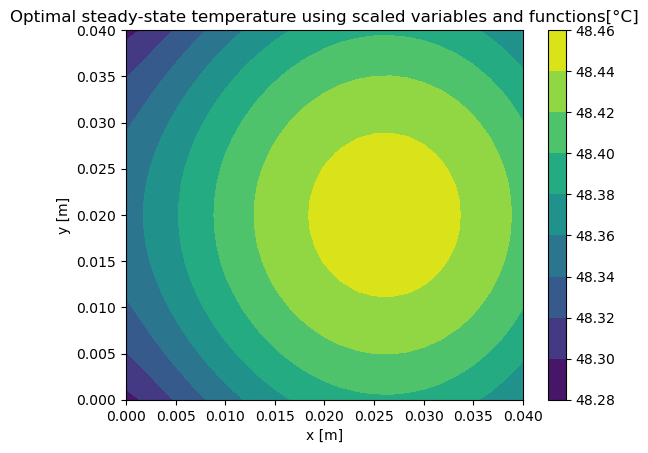

In [118]:
v_opt, a_opt, b_opt, c_opt = z_to_x(sci_opt_result_FD_scaling.x)

heq_FD_scaling.reset()
heq_FD_scaling.set_heat_generation(q_gen, a_opt, b_opt, c_opt)
heq_FD_scaling.set_fan_velocity(v_opt)
heq_FD_scaling.solve_until_steady_state()

# plotting initial T distribution after solving
fig, ax = plt.subplots()
contour1 = ax.contourf(heq_FD_scaling.X, heq_FD_scaling.Y, heq_FD_scaling.u - 273)
fig.colorbar(contour1, ax=ax)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Optimal steady-state temperature using scaled variables and functions[°C]")
plt.show()

In [141]:
np.max(heq_FD_scaling.u) -273

np.float64(48.45087790561155)

In [146]:
print(f'v_opt : {v_opt}')
print(f'a_opt : {a_opt}')
print(f'b_opt : {b_opt}')
print(f'c_opt : {c_opt}')
print(f'g_opt : {iter_constr_FD_scaling[-1]}')

v_opt : 20.000209831065202
a_opt : 54.52052161597825
b_opt : 54.6956133844558
c_opt : 153319.791827219
g_opt : 2.7711166694643907e-13


<>:77: SyntaxWarning: invalid escape sequence '\e'
<>:82: SyntaxWarning: invalid escape sequence '\e'
<>:77: SyntaxWarning: invalid escape sequence '\e'
<>:82: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_493121/3886216930.py:77: SyntaxWarning: invalid escape sequence '\e'
  ax2.set_ylabel('$\eta$', color='red')
/tmp/ipykernel_493121/3886216930.py:82: SyntaxWarning: invalid escape sequence '\e'
  labels = ['$T_{LSE}$', '$\eta$']


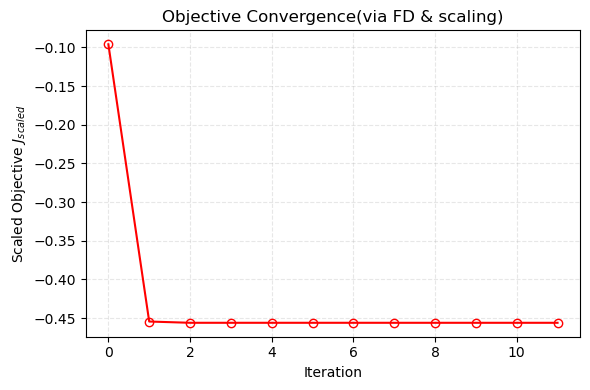

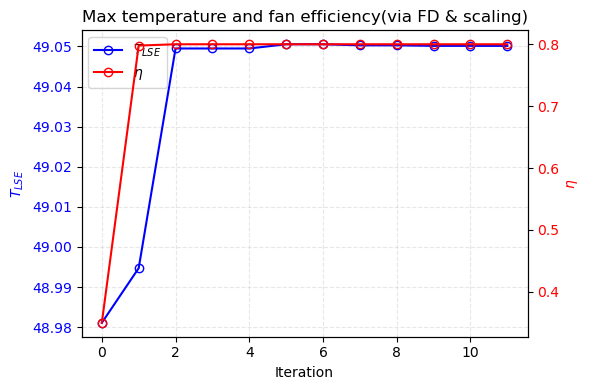

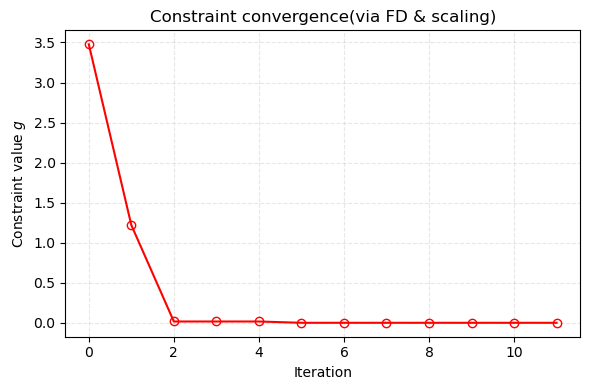

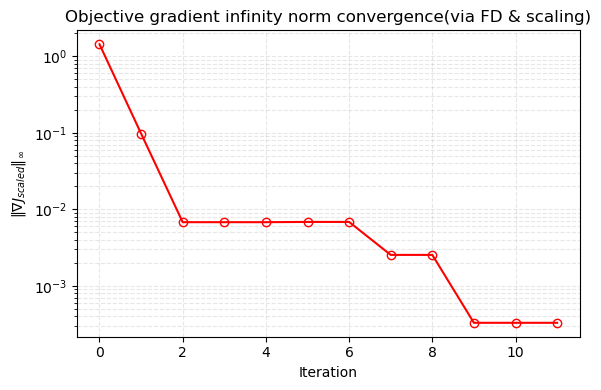

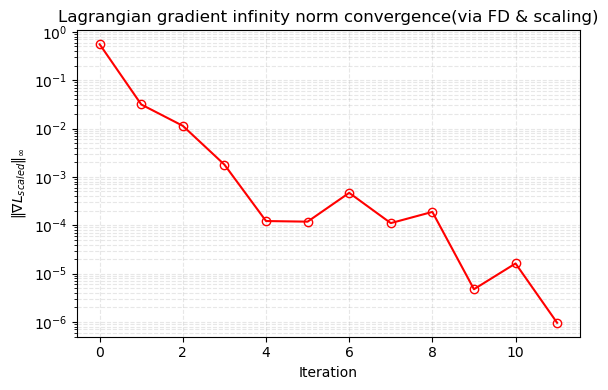

In [138]:
# ---------- 공통: iteration index ----------
iters = np.arange(len(iter_obj_FD_scaling))

# 공통 스타일
marker_style = dict(
    marker='o',
    markerfacecolor='none',   # 속 비우기
    color='red',
    markeredgecolor='red',
    linewidth=1.5,
    markersize=6,
)

# ============================================================
# (1) f_k 개별 그래프 (linear scale)
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    iters,
    iter_obj_FD_scaling,
    **marker_style
)
ax.set_xlabel('Iteration')
ax.set_ylabel('Scaled Objective $J_{scaled}$')
ax.grid(True, which='both', linestyle='--', alpha=0.3)

plt.title('Objective Convergence(via FD & scaling)')
plt.tight_layout()
plt.show()

# ============================================================
# (2) eta + T_max 한 그림, 두 개의 y축
#     - eta = 빨강
#     - T_max = 파랑
# ============================================================

fig, ax1 = plt.subplots(figsize=(6, 4))

# T_max (blue)
marker_style_blue = {
    "marker": 'o',
    "markerfacecolor": 'none',
    "markeredgecolor": 'blue',
    "color": 'blue',
    "linewidth": 1.5,
    "markersize": 6,
}

line1, = ax1.plot(
    iters,
    iter_maxT_FD_scaling,
    **marker_style_blue
)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('$T_{LSE}$', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, which='both', linestyle='--', alpha=0.3)

# eta (red)
ax2 = ax1.twinx()
marker_style_red = {
    "marker": 'o',
    "markerfacecolor": 'none',
    "markeredgecolor": 'red',
    "color": 'red',
    "linewidth": 1.5,
    "markersize": 6,
}

line2, = ax2.plot(
    iters,
    iter_eta_FD_scaling,
    **marker_style_red
)
ax2.set_ylabel('$\eta$', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# legend
lines = [line1, line2]
labels = ['$T_{LSE}$', '$\eta$']
ax1.legend(lines, labels, loc='best')

plt.title('Max temperature and fan efficiency(via FD & scaling)')
plt.tight_layout()
plt.show()

# ============================================================
# (3) 제약값 c_k (linear scale)
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    iters,
    iter_constr_FD_scaling,
    **marker_style
)
ax.set_xlabel('Iteration')
ax.set_ylabel('Constraint value $g$')
ax.grid(True, which='both', linestyle='--', alpha=0.3)

plt.title("Constraint convergence(via FD & scaling)")
plt.tight_layout()
plt.show()

# ============================================================
# (4) grad f (objective gradient) - log scale
# ============================================================

grad_obj_arr = np.array(iter_grad_obj_FD_scaling)   # shape: (n_iter, n_var)
grad_obj_norm = np.linalg.norm(grad_obj_arr, axis=1, ord=np.inf)

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    iters,
    grad_obj_norm,
    **marker_style
)
ax.set_yscale('log')
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\|\nabla J_{scaled}\|_{\infty}$')
ax.grid(True, which='both', linestyle='--', alpha=0.3)

plt.title('Objective gradient infinity norm convergence(via FD & scaling)')
plt.tight_layout()
plt.show()

# ============================================================
# (5) grad L (Lagrangian gradient) - log scale
# ============================================================

grad_L_arr = np.array(iter_grad_L_FD_scaling)   # shape: (n_iter, n_var)
grad_L_norm = np.linalg.norm(grad_L_arr, axis=1, ord=np.inf)

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    iters,
    grad_L_norm,
    **marker_style
)
ax.set_yscale('log')
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\|\nabla L_{scaled}\|_{\infty}$')
ax.grid(True, which='both', linestyle='--', alpha=0.3)

plt.title('Lagrangian gradient infinity norm convergence(via FD & scaling)')
plt.tight_layout()
plt.show()

## Compare the value of Finite Differentiation(FD) with Automatic Differentiation(AD)

In [120]:
# numpy array로 변환
grad_obj_FD_scaling_arr = np.array(iter_grad_obj_FD_scaling)

# 열 이름 정의 (원하면 바꿀 수 있음)
columns = [f'g{i}' for i in range(grad_obj_FD_scaling_arr.shape[1])]

# pandas DataFrame 생성
df_grad_obj_FD_scaling_arr = pd.DataFrame(grad_obj_FD_scaling_arr, columns=columns)

# iteration index 표시
df_grad_obj_FD_scaling_arr.index.name = 'iter'

pd.options.display.float_format = '{:.6e}'.format

print(df_grad_obj_FD_scaling_arr)

                g0           g1           g2           g3
iter                                                     
0    -1.440114e+00 2.805144e-06 2.739951e-06 2.733711e-04
1     9.798484e-02 2.756715e-06 2.644956e-06 2.637282e-04
2    -6.810620e-03 3.419816e-06 3.285706e-06 3.282949e-04
3    -6.810620e-03 3.419816e-06 3.285706e-06 3.282949e-04
4    -6.810620e-03 3.419816e-06 3.285706e-06 3.282949e-04
5    -6.860875e-03 3.445894e-06 3.304332e-06 3.306009e-04
6    -6.860875e-03 3.445894e-06 3.304332e-06 3.306009e-04
7    -2.543941e-03 3.423542e-06 3.293157e-06 3.299564e-04
8    -2.543941e-03 3.423542e-06 3.293157e-06 3.299564e-04
9    -2.466887e-04 3.434718e-06 3.293157e-06 3.297627e-04
10   -2.466887e-04 3.434718e-06 3.293157e-06 3.297627e-04
11   -4.829094e-05 3.419816e-06 3.285706e-06 3.297552e-04


## Optimization - Automatic Differetiation(AD) & Scaling

In [4]:
def T0_jax(x_mesh, y_mesh, lx, ly):
    """
    JAX 기반 초기 온도 분포 생성
    """
    # 70 * sin(x*pi/lx) * sin(y*pi/ly) + 293
    T_0 = 70 * jnp.sin(x_mesh * jnp.pi / lx) * jnp.sin(y_mesh * jnp.pi / ly) + 293.0
    return T_0

In [5]:
lx = .04  # length in x direction
ly = .04  # length in y direction
z = .04  # height of the domain
N = 25    # number of grid points in x, y direction
k_Si = 149  # thermal conductivity of silicon
rho_Si = 2323  # density of silicon
cp_Si = 704.611  # specific heat capacity of silicon
CFL = .1 # CFL number

heq_jax = HeatEquation2D_JAX(lx, ly, z, N, N, k=k_Si, rho=rho_Si, cp=cp_Si, CFL=CFL)
u0 = T0_jax(heq_jax.X, heq_jax.Y, .04, .04)

In [6]:
# ------------- Scaling Variables -------------
def x_to_z_jax(x_jnp):
    """
    Scale the design variable x to the optimization variable z.
    """
    v_min, v_max = .0, 30.0
    a_min, a_max = .0, 1e5
    b_min, b_max = .0, 1e5
    c_min, c_max = .0, 2e5

    v_scaled = (x_jnp[0] - v_min) / (v_max - v_min)
    a_scaled = (x_jnp[1] - a_min) / (a_max - a_min)
    b_scaled = (x_jnp[2] - b_min) / (b_max - b_min)
    c_scaled = (x_jnp[3] - c_min) / (c_max - c_min)

    z_jnp = jnp.array([v_scaled, a_scaled, b_scaled, c_scaled])

    return z_jnp

def z_to_x_jax(z_jnp):
    """
    Scale the optimization variable z to the actual design variable x.
    """
    v_min, v_max = .0, 30.0
    a_min, a_max = .0, 1e5
    b_min, b_max = .0, 1e5
    c_min, c_max = .0, 2e5

    v = v_min + (v_max - v_min) * z_jnp[0]
    a = a_min + (a_max - a_min) * z_jnp[1]
    b = b_min + (b_max - b_min) * z_jnp[2]
    c = c_min + (c_max - c_min) * z_jnp[3]

    x_jnp = jnp.array([v, a, b, c])

    return x_jnp

# ------------- Objective function -------------
@jax.jit
def f_jax_scaling(z_jnp):
    x_jnp = z_to_x_jax(z_jnp)
    v, a, b, c = x_jnp[0], x_jnp[1], x_jnp[2], x_jnp[3]
    final_u = heq_jax.solve_steady_state(v, (a, b, c), u0, max_iter=50000)
    # max_T = jnp.max(final_u)
    beta = 10.0  # 로그섬지수
    T_max = jax.nn.logsumexp(beta * final_u) / beta
    T_ref = 350.0
    T_max_scaling = T_max / T_ref

    eta = -0.002 * v**2 + 0.08 * v
    return 0.2 * T_max_scaling - 0.8 * eta

grad_f_jax = jax.grad(f_jax_scaling)

# 2) SciPy용 래퍼 (numpy <-> jax 변환)
def f_jax_wrapped(z_np):
    print(f'objective function starts to be evaluated (JAX)')
    z_jnp = jnp.asarray(z_np)
    return float(f_jax_scaling(z_jnp))

def grad_f_wrapped(z_np):
    z_jnp = jnp.asarray(z_np)
    g = grad_f_jax(z_jnp) # JAX gradient (DeviceArray)
    return np.asarray(g, dtype=float)

# ------------- Constraint function -------------
@jax.jit
def c_jax(z_jnp):
    # 전체 발열량이 10W여야 함
    x_jnp = z_to_x_jax(z_jnp)
    a = x_jnp[1]
    b = x_jnp[2]
    c = x_jnp[3]
    total_q = heq_jax.get_total_heat_generation((a, b, c))
    return (total_q - 10.0) * .1 # 스케일링

grad_c_jax = jax.grad(c_jax)

# 2) SciPy용 래퍼 (numpy <-> jax 변환)
def c_jax_wrapped(z_np):
    z_jnp = jnp.asarray(z_np)
    return float(c_jax(z_jnp))

def grad_c_wrapped(z_np):
    z_jnp = jnp.asarray(z_np)
    g = grad_c_jax(z_jnp) # JAX gradient (DeviceArray)
    return np.asarray(g, dtype=float)

In [ ]:
grad_obj_AD_scaling_arr = []

for i in range(3):
    z_np = iter_z_FD_scaling[i]        # i번째 iteration의 z
    grad_val = grad_f_wrapped(z_np)    # JAX AD gradient 계산
    grad_obj_AD_scaling_arr.append(grad_val)
    print(f"[Iteration {i}] z = {z_np}")
    print(f"[Iteration {i}] grad f(z) = {grad_val}")
    print()

[Iteration 0] z = [0.667 0.001 0.001 0.767]
[Iteration 0] grad f(z) = [-0.  0.  0.  0.]

[Iteration 1] z = [0.667 0.001 0.001 0.767]
[Iteration 1] grad f(z) = [-0.  0.  0.  0.]

[Iteration 2] z = [0.667 0.001 0.001 0.767]
[Iteration 2] grad f(z) = [-0.  0.  0.  0.]



In [143]:
# 원하면 numpy array로 변환도 가능
grad_obj_AD_scaling_arr = np.array(grad_obj_AD_scaling_arr)

# 열 이름 정의 (원하면 바꿀 수 있음)
columns = [f'g{i}' for i in range(grad_obj_AD_scaling_arr.shape[1])]

# pandas DataFrame 생성
df_grad_obj_AD_scaling_arr = pd.DataFrame(grad_obj_AD_scaling_arr, columns=columns)

# iteration index 표시
df_grad_obj_AD_scaling_arr.index.name = 'iter'

pd.options.display.float_format = '{:.6e}'.format

print(df_grad_obj_AD_scaling_arr)

                g0           g1           g2           g3
iter                                                     
0    -4.022676e-05 3.032660e-06 2.916835e-06 2.916835e-04
1    -2.387134e-04 3.032661e-06 2.916835e-06 2.916835e-04
2    -2.387134e-04 3.032661e-06 2.916835e-06 2.916835e-04


In [144]:
# 0번째 행 비교 (iteration 0)
df_cmp_0 = pd.DataFrame({
    "FD_grad": df_grad_obj_FD_scaling_arr.iloc[0],
    "AD_grad": df_grad_obj_AD_scaling_arr.iloc[0],
})
df_cmp_0["|(FD_grad - AD_grad)/AD_grad| [%]"] = 100*np.abs(df_cmp_0["FD_grad"] - df_cmp_0["AD_grad"])/np.abs(df_cmp_0["AD_grad"])
df_cmp_0["|(FD_grad - AD_grad)/AD_grad| [%]"] = df_cmp_0["|(FD_grad - AD_grad)/AD_grad| [%]"].apply(lambda x: f"{x:.4f}")
print("\n=== Iteration 0 comparison ===")
print(df_cmp_0)

# 1번째 행 비교 (iteration 1)
df_cmp_1 = pd.DataFrame({
    "FD_grad": df_grad_obj_FD_scaling_arr.iloc[1],
    "AD_grad": df_grad_obj_AD_scaling_arr.iloc[1],
})
df_cmp_1["|(FD_grad - AD_grad)/AD_grad| [%]"] = 100*np.abs(df_cmp_1["FD_grad"] - df_cmp_1["AD_grad"])/np.abs(df_cmp_1["AD_grad"])
df_cmp_1["|(FD_grad - AD_grad)/AD_grad| [%]"] = df_cmp_1["|(FD_grad - AD_grad)/AD_grad| [%]"].apply(lambda x: f"{x:.4f}")
print("\n=== Iteration 1 comparison ===")
print(df_cmp_1)

# 2번째 행 비교 (iteration 2)
df_cmp_2 = pd.DataFrame({
    "FD_grad": df_grad_obj_FD_scaling_arr.iloc[2],
    "AD_grad": df_grad_obj_AD_scaling_arr.iloc[2],
})
df_cmp_2["|(FD_grad - AD_grad)/AD_grad| [%]"] = 100*np.abs(df_cmp_2["FD_grad"] - df_cmp_2["AD_grad"])/np.abs(df_cmp_2["AD_grad"])
df_cmp_2["|(FD_grad - AD_grad)/AD_grad| [%]"] = df_cmp_2["|(FD_grad - AD_grad)/AD_grad| [%]"].apply(lambda x: f"{x:.4f}")
print("\n=== Iteration 2 comparison ===")
print(df_cmp_2)


=== Iteration 0 comparison ===
         FD_grad       AD_grad |(FD_grad - AD_grad)/AD_grad| [%]
g0 -1.440114e+00 -4.022676e-05                      3579891.3646
g1  2.805144e-06  3.032660e-06                            7.5022
g2  2.739951e-06  2.916835e-06                            6.0643
g3  2.733711e-04  2.916835e-04                            6.2782

=== Iteration 1 comparison ===
        FD_grad       AD_grad |(FD_grad - AD_grad)/AD_grad| [%]
g0 9.798484e-02 -2.387134e-04                        41147.0667
g1 2.756715e-06  3.032661e-06                            9.0991
g2 2.644956e-06  2.916835e-06                            9.3210
g3 2.637282e-04  2.916835e-04                            9.5841

=== Iteration 2 comparison ===
         FD_grad       AD_grad |(FD_grad - AD_grad)/AD_grad| [%]
g0 -6.810620e-03 -2.387134e-04                         2753.0534
g1  3.419816e-06  3.032661e-06                           12.7662
g2  3.285706e-06  2.916835e-06                           12.6463

In [ ]:
iter_x_jax_scaling = []

iter_maxT_jax_scaling = []
iter_eta_jax_scaling = []

iter_obj_jax_scaling = []
iter_grad_obj_jax_scaling = []

iter_constr_jax_scaling = []
iter_grad_constr_jax_scaling = []

iter_grad_L_jax_scaling = []
# iter_grad_norm_jax = []


def opt_iter_callback_jax_scaling(zk, state):
    """Called by trust-constr once per iteration with current zk."""
    print(f'\n{state.nit}-th iteration callback ...')
    xk = z_to_x_jax(zk)
    v = xk[0]
    a = xk[1]
    b = xk[2]
    c = xk[3]
    eta = -0.002 * v**2 + 0.08 * v
    maxT = 350.0 * 5 * (state.fun + 0.8 * eta) # since obj = w1*maxT/T_ref - w2*eta
    fk = .2*maxT - .8*eta
    constr = c_jax_wrapped(zk)*10

    iter_x_jax_scaling.append(np.array(xk, copy=True))
    iter_obj_jax_scaling.append(fk)
    iter_eta_jax_scaling.append(eta)
    iter_maxT_jax_scaling.append(maxT)  
    iter_constr_jax_scaling.append(constr)
    iter_grad_obj_jax_scaling.append(state.grad.copy())
    # iter_grad_constr.append([jac.copy() for jac in state.jac])
    iter_grad_L_jax_scaling.append(state.lagrangian_grad)

    print(f'Current x: {xk}')
    print(f'Current objective: {fk}')
    print(f'Current maxT: {maxT}')
    print(f'Current eta: {eta}')
    print(f'Current constraint value: {constr}')
    print(f'gradient of objective: {state.grad}')
    # print(f'gradient of constraints: {[jac for jac in state.jac]}')
    print(f'gradient of Lagrangian: {state.lagrangian_grad}')
    print()

In [8]:
v0 = 5.0
a0 = 0.0
b0 = 0.0
c0 = (1.0*10**5 - 0.02*b0 - 0.02*a0)  # same formula as before
x0 = np.array([v0, a0, b0, c0])

z0 = np.asarray(x_to_z_jax(jnp.array(x0)), dtype=float)

# ---- Bounds for inputs ----
z_bounds = [
    (0.0, 1.0),        # v
    (-np.inf, np.inf),  # a
    (-np.inf, np.inf),  # b
    (0.0, 1.0),      # c
]

# Using NonlinearConstraint from scipy
constraints = [{'type': 'eq', 'fun': c_jax_wrapped, 'jac': grad_c_wrapped}]

# --- Optimization with automatic differentiation ---
sci_opt_result_jax_scaling = sci_opt.minimize(fun=f_jax_wrapped, x0=z0, method='trust-constr', jac=grad_f_wrapped, bounds=z_bounds, constraints=constraints, tol=1e-6, callback=opt_iter_callback_jax_scaling, options={'maxiter': 3})

objective function starts to be evaluated (JAX)

1-th iteration callback ...
Current x: [5.e+00 0.e+00 0.e+00 1.e+05]
Current objective: 64.1054458618164
Current maxT: 321.9272155761719
Current eta: 0.34999996423721313
Current constraint value: -3.5999998450279236
gradient of objective: [-1.44011188e+00  2.73484488e-06  2.67792961e-06  2.67792930e-04]
gradient of Lagrangian: [-5.53072678e-01  5.68985850e-08 -1.66838947e-11 -5.68818959e-10]

objective function starts to be evaluated (JAX)


/home/chiyoung0/miniconda3/envs/general_purpose/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:728: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)



2-th iteration callback ...
Current x: [ 2.11155930e+01 -1.24522057e+02 -1.24516525e+02  1.35832719e+05]
Current objective: 63.75019073486328
Current maxT: 321.94097900390625
Current eta: 0.7975108027458191
Current constraint value: -1.30702406167984
gradient of objective: [1.07045248e-01 2.69710472e-06 2.58428668e-06 2.58428714e-04]
gradient of Lagrangian: [ 3.31084034e-02 -8.27564225e-04 -8.27677043e-04  1.65524123e-05]

objective function starts to be evaluated (JAX)

3-th iteration callback ...
Current x: [2.0281248e+01 1.6980719e+01 1.6989115e+01 1.5569650e+05]
Current objective: 63.7588005065918
Current maxT: 321.99334716796875
Current eta: 0.7998417615890503
Current constraint value: -0.03538036486133933
gradient of objective: [2.69379951e-02 3.12239149e-06 3.00505349e-06 3.00505431e-04]
gradient of Lagrangian: [ 1.47900773e-02 -2.67712435e-03 -2.67724168e-03  5.35436591e-05]



In [ ]:
v_opt, a_opt, b_opt, c_opt = z_to_x(sci_opt_result_jax_scaling.x)

heq_FD_scaling.reset()
heq_FD_scaling.set_heat_generation(q_gen, a_opt, b_opt, c_opt)
heq_FD_scaling.set_fan_velocity(v_opt)
heq_FD_scaling.solve_until_steady_state()

# plotting initial T distribution after solving
fig, ax = plt.subplots()
contour1 = ax.contourf(heq_FD_scaling.X, heq_FD_scaling.Y, heq_FD_scaling.u - 273)
fig.colorbar(contour1, ax=ax)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Optimal steady-state temperature using scaled variables and functions[°C]")
plt.show()

In [14]:
v_opt, a_opt, b_opt, c_opt = z_to_x_jax(sci_opt_result_jax_scaling.x)


In [16]:
print(f'v_opt : {v_opt}')
print(f'a_opt : {a_opt}')
print(f'b_opt : {b_opt}')
print(f'c_opt : {c_opt}')
print(f'g_opt : {iter_constr_jax_scaling[-1]}')

v_opt : 20.281248092651367
a_opt : 16.9807186126709
b_opt : 16.98911476135254
c_opt : 155696.5
g_opt : -0.03538036486133933


<>:77: SyntaxWarning: invalid escape sequence '\e'
<>:82: SyntaxWarning: invalid escape sequence '\e'
<>:77: SyntaxWarning: invalid escape sequence '\e'
<>:82: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_564172/2696200447.py:77: SyntaxWarning: invalid escape sequence '\e'
  ax2.set_ylabel('$\eta$', color='red')
/tmp/ipykernel_564172/2696200447.py:82: SyntaxWarning: invalid escape sequence '\e'
  labels = ['$T_{LSE}$', '$\eta$']


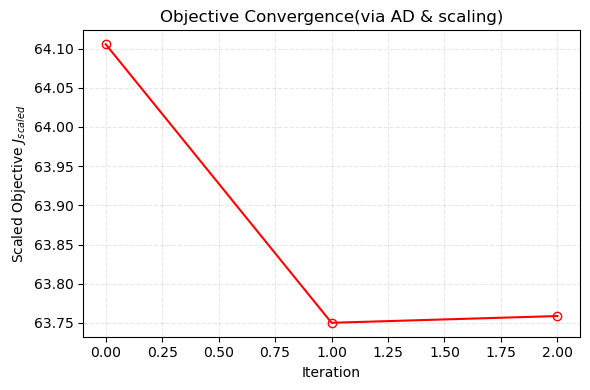

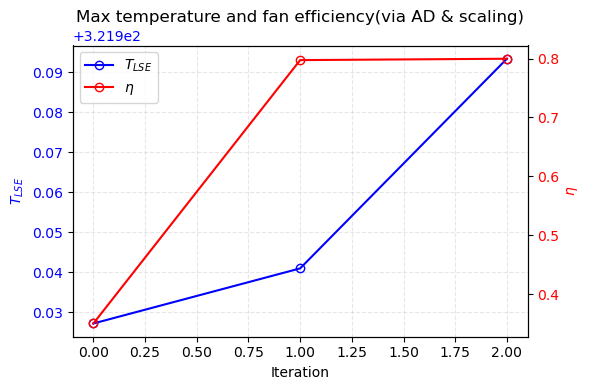

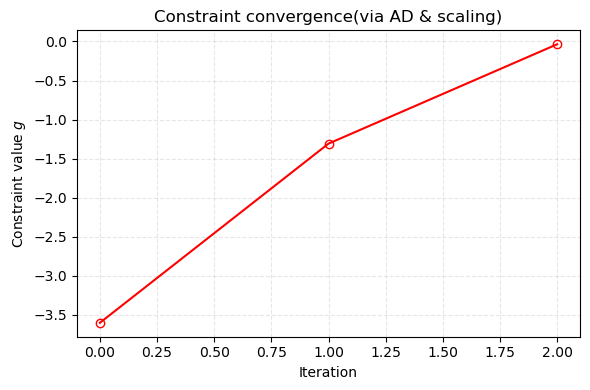

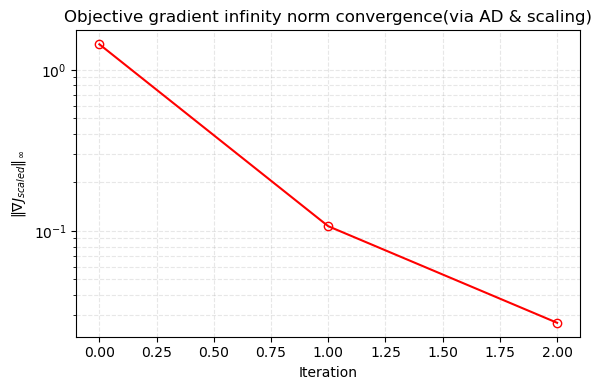

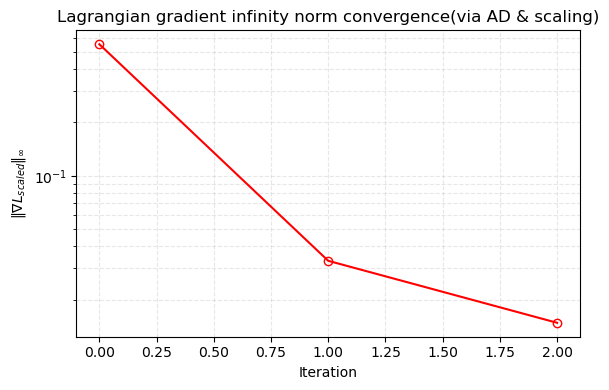

In [12]:
# ---------- 공통: iteration index ----------
iters = np.arange(len(iter_obj_jax_scaling))

# 공통 스타일
marker_style = dict(
    marker='o',
    markerfacecolor='none',   # 속 비우기
    color='red',
    markeredgecolor='red',
    linewidth=1.5,
    markersize=6,
)

# ============================================================
# (1) f_k 개별 그래프 (linear scale)
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    iters,
    iter_obj_jax_scaling,
    **marker_style
)
ax.set_xlabel('Iteration')
ax.set_ylabel('Scaled Objective $J_{scaled}$')
ax.grid(True, which='both', linestyle='--', alpha=0.3)

plt.title('Objective Convergence(via AD & scaling)')
plt.tight_layout()
plt.show()

# ============================================================
# (2) eta + T_max 한 그림, 두 개의 y축
#     - eta = 빨강
#     - T_max = 파랑
# ============================================================

fig, ax1 = plt.subplots(figsize=(6, 4))

# T_max (blue)
marker_style_blue = {
    "marker": 'o',
    "markerfacecolor": 'none',
    "markeredgecolor": 'blue',
    "color": 'blue',
    "linewidth": 1.5,
    "markersize": 6,
}

line1, = ax1.plot(
    iters,
    iter_maxT_jax_scaling,
    **marker_style_blue
)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('$T_{LSE}$', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, which='both', linestyle='--', alpha=0.3)

# eta (red)
ax2 = ax1.twinx()
marker_style_red = {
    "marker": 'o',
    "markerfacecolor": 'none',
    "markeredgecolor": 'red',
    "color": 'red',
    "linewidth": 1.5,
    "markersize": 6,
}

line2, = ax2.plot(
    iters,
    iter_eta_jax_scaling,
    **marker_style_red
)
ax2.set_ylabel('$\eta$', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# legend
lines = [line1, line2]
labels = ['$T_{LSE}$', '$\eta$']
ax1.legend(lines, labels, loc='best')

plt.title('Max temperature and fan efficiency(via AD & scaling)')
plt.tight_layout()
plt.show()

# ============================================================
# (3) 제약값 c_k (linear scale)
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    iters,
    iter_constr_jax_scaling,
    **marker_style
)
ax.set_xlabel('Iteration')
ax.set_ylabel('Constraint value $g$')
ax.grid(True, which='both', linestyle='--', alpha=0.3)

plt.title("Constraint convergence(via AD & scaling)")
plt.tight_layout()
plt.show()

# ============================================================
# (4) grad f (objective gradient) - log scale
# ============================================================

grad_obj_arr = np.array(iter_grad_obj_jax_scaling)   # shape: (n_iter, n_var)
grad_obj_norm = np.linalg.norm(grad_obj_arr, axis=1, ord=np.inf)

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    iters,
    grad_obj_norm,
    **marker_style
)
ax.set_yscale('log')
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\|\nabla J_{scaled}\|_{\infty}$')
ax.grid(True, which='both', linestyle='--', alpha=0.3)

plt.title('Objective gradient infinity norm convergence(via AD & scaling)')
plt.tight_layout()
plt.show()

# ============================================================
# (5) grad L (Lagrangian gradient) - log scale
# ============================================================

grad_L_arr = np.array(iter_grad_L_jax_scaling)   # shape: (n_iter, n_var)
grad_L_norm = np.linalg.norm(grad_L_arr, axis=1, ord=np.inf)

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    iters,
    grad_L_norm,
    **marker_style
)
ax.set_yscale('log')
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\|\nabla L_{scaled}\|_{\infty}$')
ax.grid(True, which='both', linestyle='--', alpha=0.3)

plt.title('Lagrangian gradient infinity norm convergence(via AD & scaling)')
plt.tight_layout()
plt.show()